Introduction

In this project, we are using the Instacart dataset from Kaggle to predict whether a user will reorder a previously ordered product. To do so, we will do the following

    1. Manually create our own validate and synthetic test datasets
    2. Feature Engineering
    3. Build and train a model
    4. Tune the model(s)
    5. Determine the most important features


To begin, we will import our datasets

In [1]:

import load_data
import feature_engineering
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, classification_report, f1_score
from sklearn.metrics import f1_score, classification_report, make_scorer
import gc 
import train_model
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)

# import all the datasets
# 1. Orders
# | Column                   | Meaning                    |
# | ------------------------ | -------------------------- |
# | `order_id`               | Unique order identifier    |
# | `user_id`                | Customer identifier        |
# | `eval_set`               | `prior` / `train` / `test` |
# | `order_number`           | Order sequence per user    |
# | `order_dow`              | Day of week (0–6)          |
# | `order_hour_of_day`      | Hour order was placed      |
# | `days_since_prior_order` | Gap since last order       |
#
# 2. Order products prior
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 3. Order products train
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 4. Products
# | Column          | Meaning             |
# | --------------- | ------------------- |
# | `product_id`    | Product key         |
# | `product_name`  | Product description |
# | `aisle_id`      | Sub-category        |
# | `department_id` | High-level category |
#
# 5. Aisles
# | Column     | Meaning    |
# | ---------- | ---------- |
# | `aisle_id` | Join key   |
# | `aisle`    | Aisle name |
#
#6. Departments
# | Column          | Meaning         |
# | --------------- | --------------- |
# | `department_id` | Join key        |
# | `department`    | Department name |

orders, order_products_prior, order_products_train, products, aisles, departments = load_data.get_data()

orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [2]:
orders['eval_set'].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

The table below shows how the prior, train and test eval sets were split. The test eval set does not tell us which products were re-ordered as it was hidden for the competition. 

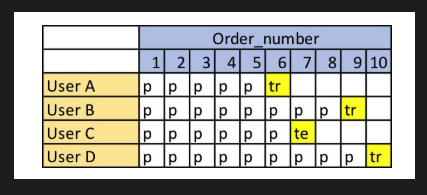

<span style="font-size:20px;">Preoprocessing</span>

In this project, we are utilizing the Instacart dataset from Kaggle. In the original competition, the eval_set = 'test' was reserved for hidden evaluation (i.e. no "Order_products_test" dataset to check if a user reordered). To validate our model's performance locally, we will synthetically generate a custom 'test' set by isolating the final known order for each user in the "test" category. To do so, we take the latest/most recent order from the eval_set='prior' for the test users.

<span style="font-size:12px;">
    <b>
    1. Synthetically create our own test orders <br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.1 From the orders table, get the test orders and obtain the unique users from the test orders<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.2 Obtain the prior orders from the orders table for the specific test users<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.3 Get the max (most recent) prior order and update the 'eval_set' to 'test_synthetic'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.4 Remove the 'test_synthetic' orders from 'order_products_prior' to create a order_products_test subset which will be used as a y to validate <br><br>
</span>

<span style="font-size:12px;">
    <b>
    2. Split our test data into train and validate<br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1 Obtain the validate orders from the train orders and set the 'eval_set' to 'validate'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2 Take the validate orders from order_products_train to create order_products_validate<br>
    
</span>




In [3]:
#1 Obtain test users

test_users = orders[orders['eval_set']=='test']['user_id'].copy()
train_users = orders[orders['eval_set']=='train']['user_id'].copy()


In [4]:
#1.2 Obtain the prior orders for the test users

test_users_prior_orders = orders[(orders['eval_set']=='prior') & (orders['user_id'].isin(test_users))].copy()
test_users_prior_orders[test_users_prior_orders['user_id']==15].tail()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
147,1911383,15,prior,18,2,11,7.0
148,2345592,15,prior,19,5,11,3.0
149,2994589,15,prior,20,1,13,10.0
150,2715276,15,prior,21,1,9,7.0
151,487368,15,prior,22,1,10,14.0


In [5]:
#1.3 Obtain the most recent prior order for the test user and update eval set to 'test_synthetic'

test_user_most_recent_order_number = test_users_prior_orders.groupby(['user_id'])['order_number'].transform('max')
synthetic_test_df = test_users_prior_orders[test_users_prior_orders['order_number']==test_user_most_recent_order_number]

synthetic_test_order_ids = synthetic_test_df['order_id'].copy()
orders.loc[(orders['order_id'].isin(synthetic_test_order_ids)), 'eval_set' ] = 'test_synthetic'

In [6]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train              131209
test_synthetic      75000
test                75000
Name: count, dtype: int64

In [7]:
#1.4 Removing the 'test_synthetic' orders from 'order_products_prior'

order_products_test_synthetic = order_products_prior[order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()
order_products_prior = order_products_prior[~order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()


In [8]:
#2.1 Train, Validate split our train orders data

from sklearn.model_selection import train_test_split

y_train_users, y_validate_users = train_test_split(train_users, test_size=0.3, random_state=123)

orders.loc[(orders['user_id'].isin(y_validate_users)) & (orders['eval_set']=='train'), 'eval_set'] = 'validate'

validate_orders = orders[(orders['eval_set']=='validate')]['order_id']
order_products_validate = order_products_train[order_products_train['order_id'].isin(validate_orders)]
order_products_train = order_products_train[~(order_products_train['order_id'].isin(validate_orders))]



In [9]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train               91846
test_synthetic      75000
test                75000
validate            39363
Name: count, dtype: int64

In [10]:
#Merging to get product data

prior_orders = orders[orders['eval_set']=='prior'].copy()

op = prior_orders.merge(
    order_products_prior,
    how='left',
    on='order_id'
)

In [11]:
op.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0


Now that we split our data into train, validate and test, we will move onto feature engineering. The feature engineering will be done at several levels:

1. User level                       (To determine the baviour of the user)
2. Product level                    (To determine the popularity of a product)
3. User-Product level               (To determine the relationship between the user and product)
4. Aisle level                      (To determine preferencese and popularity of an aisle)
5. Department level                 (To determine preferencese and popularity of a department)
6. User-Aisle level                 (To determine the relationship between the user and aisle)
7. User-Department level            (To determine the relationship between the user and department)

In [12]:
#Calling our get_feature methods

user_features = feature_engineering.get_user_features(op)

In [13]:
product_features = feature_engineering.get_product_features(op)

In [14]:
user_product_features = feature_engineering.get_user_product_features(op)

In [15]:
user_product_features.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3


In [16]:
#Creating aisle and department features

opad = op.merge(
    products[['product_id', 'aisle_id', 'department_id']], 
    how='left',
    on='product_id'
)

opad=opad[['user_id', 'order_id', 'product_id', 'reordered', 'aisle_id', 'department_id']]
opad.head()

,user_id,order_id,product_id,reordered,aisle_id,department_id
0,1,2539329,196,0,77,7
1,1,2539329,14084,0,91,16
2,1,2539329,12427,0,23,19
3,1,2539329,26088,0,23,19
4,1,2539329,26405,0,54,17


In [17]:
aisle_and_department_features = feature_engineering.get_aisle_department_features(opad)

In [18]:
# Merge all the fetures together from the prior data

df = user_product_features.merge(
    user_features,
    how='left',
    on='user_id'
)

df = df.merge(
    product_features,
    how='left',
    on='product_id'
)

df = df.merge(
    aisle_and_department_features,
    how='left',
    on=['user_id', 'product_id']
)

df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3


In [19]:
#Now that we have all the features, we want to merge with the most recent train, validate or test order to obtain the y varaible

future_orders = orders[orders['eval_set'].isin(['train', 'validate', 'test_synthetic'])].copy()
future_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.0
25,1492625,2,train,15,1,11,30.0
37,1402502,3,test_synthetic,12,1,15,15.0
43,2557754,4,test_synthetic,5,5,13,0.0
49,2196797,5,validate,5,0,11,6.0


In [20]:
df = df.merge(
    future_orders,
    how='left',
    on='user_id'
)

In [21]:
df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0


Now that we comlpleted our feature engineering, we split our dataset into train, validate and test sets. 

In [22]:
model_train_data = feature_engineering.get_split_data(df, 'train', order_products_train)
model_validate_data = feature_engineering.get_split_data(df, 'validate', order_products_validate)
model_test_synthetic_data = feature_engineering.get_split_data(df, 'test_synthetic', order_products_test_synthetic)


In [23]:
model_train_data.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0,1.0,1.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,6.0,1.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0,NaN,0.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,NaN,0.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0,7.0,1.0


Next, we will train several models to determine which one(s) perform best, then followed by hypertuning the parameters with randomized search. Since our dataset is imbalanced with a ratio of roughly 1:9, we will evaluate performance using Precision-Recall AUC (PR AUC) instead of ROC AUC or Accuracy as it can be misleading. For example, a model could achieve 90% accuracy simply by predicting that no items are reordered. To address the imbalance while retaining as much data as possible, we will use scale weights within our models instead of undersampling. The models we will be testing are XGBoost, LightGBM, and CatBoost, using Logistic Regression as a baseline.

In [42]:
cols_to_drop = ['order_id', 'eval_set', 'add_to_cart_order', 'reordered']

X_train = model_train_data.drop(columns=cols_to_drop)
y_train = model_train_data['reordered']

X_train = X_train.astype('float32') #downcast to save memory

X_val = model_validate_data.drop(columns=cols_to_drop)
y_val = model_validate_data['reordered']

train_ratio = (y_train==0).sum() / (y_train==1).sum()
val_ratio = (y_val==0).sum() / (y_val==1).sum()

X_test = model_test_synthetic_data.drop(columns=cols_to_drop)
y_test = model_test_synthetic_data['reordered']

print(f"The train dataset is unbalanced on a scale from 1: {train_ratio:.3f}")
print(f"The validate dataset is unbalanced on a scale from 1: {val_ratio:.3f}")

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.1,
    'tree_method': 'hist', #groups the values into buckets so its faster to split into branches and leaves
    'scale_pos_weight': int(train_ratio)-1, #puts more weight on the reorders on a scale of 1 : train_ratio
    'seed':123
}

xgb_train_dmatrix = xgb.DMatrix(X_train, y_train)
xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)

xgb_train_y_pred = xgb_model.predict(xgb_train_dmatrix)
xgb_train_pr_auc = average_precision_score(y_train, xgb_train_y_pred)
print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")


xgb_val_dmatrix = xgb.DMatrix(X_val, y_val)
xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_pr_auc = average_precision_score(y_val, xgb_val_y_pred)
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")



The train dataset is unbalanced on a scale from 1: 9.210
The validate dataset is unbalanced on a scale from 1: 9.260
Train PR AUC: 0.432
Validation PR AUC: 0.426


In [43]:
# We want to find the best threshold based on the F1 score
# Base it off the validation set to prevent over fitting
threshold = np.arange(0.6, 0.925, 0.025)

xgb_validate_best_threshold = train_model.threshold_optimized_f1(y_val, xgb_val_y_pred, threshold)


print(f"The best threshold for XGBoost validation data was: {xgb_validate_best_threshold:.2f}")
xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)

The best threshold for XGBoost validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   2298172
         1.0       0.40      0.49      0.44    248191

    accuracy                           0.88   2546363
   macro avg       0.67      0.71      0.69   2546363
weighted avg       0.89      0.88      0.88   2546363



In [44]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'scale_pos_weight': int(train_ratio)-1,
    'random_state': 123,
    'n_jobs': -1,
    'verbosity': -1 # Keeps the output clean
}


lgbm_dataset = lgb.Dataset(X_train, y_train)
lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=100)

lgbm_train_y_pred = lgbm_model.predict(X_train)
lgbm_train_pr_auc = average_precision_score(y_train, lgbm_train_y_pred)

lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_pr_auc = average_precision_score(y_val, lgbm_val_y_pred)


print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")
print(f"Validation PR AUC: {lgbm_train_pr_auc:.3f}")


Train PR AUC: 0.429
Validation PR AUC: 0.429


In [45]:

lgbm_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lgbm_val_y_pred, threshold)

print(f"The best threshold for LightGBM validation data was: {lgbm_validate_best_threshold:.2f}")
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

The best threshold for LightGBM validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   2298172
         1.0       0.40      0.49      0.44    248191

    accuracy                           0.88   2546363
   macro avg       0.67      0.71      0.69   2546363
weighted avg       0.89      0.88      0.88   2546363



In [46]:
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

cat_params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'objective': 'Logloss',
    'eval_metric': 'PRAUC',
    'scale_pos_weight': int(train_ratio) - 1,
    'random_seed': 123,
    'thread_count': -1,
    'verbose': False,
    'allow_writing_files': False
}

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(train_pool)

cat_train_y_pred = cat_model.predict(X_train, prediction_type='Probability')[:, 1]
cat_val_y_pred = cat_model.predict(X_val, prediction_type='Probability')[:, 1]

cat_train_pr_auc = average_precision_score(y_train, cat_train_y_pred)
cat_val_pr_auc = average_precision_score(y_val, cat_val_y_pred)

print(f"CatBoost Train PR AUC: {cat_train_pr_auc:.3f}")
print(f"CatBoost Validation PR AUC: {cat_val_pr_auc:.3f}")

CatBoost Train PR AUC: 0.424
CatBoost Validation PR AUC: 0.421


In [47]:
cat_validate_best_threshold = train_model.threshold_optimized_f1(y_val, cat_val_y_pred, threshold)

print(f"The best threshold for CatBoost validation data was: {cat_validate_best_threshold:.2f}")
cat_val_report_final = classification_report(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
print(cat_val_report_final)

The best threshold for CatBoost validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   2298172
         1.0       0.40      0.48      0.44    248191

    accuracy                           0.88   2546363
   macro avg       0.67      0.70      0.69   2546363
weighted avg       0.89      0.88      0.88   2546363



In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_params = {
    'max_iter': 1000,
    'C': 1.0, 
    'class_weight': {0: 1, 1: int(train_ratio) - 1},
    'random_state': 123
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train)

# [:, 1] gets the probability for the 'reorder' class
lr_train_y_pred = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_train_pr_auc = average_precision_score(y_train, lr_train_y_pred)
print(f"Logistic Regression Train PR AUC: {lr_train_pr_auc:.3f}")

lr_val_y_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pr_auc = average_precision_score(y_val, lr_val_y_pred)
print(f"Logistic Regression Validation PR AUC: {lr_val_pr_auc:.3f}")

Logistic Regression Train PR AUC: 0.404
Logistic Regression Validation PR AUC: 0.402


In [49]:
lr_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lr_val_y_pred, threshold)

print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
print(classification_report(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8)))

The best threshold for Logistic Regression validation data was: 0.65
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93   2298172
         1.0       0.38      0.49      0.42    248191

    accuracy                           0.87   2546363
   macro avg       0.66      0.70      0.68   2546363
weighted avg       0.89      0.87      0.88   2546363



In [50]:
xgb_val_f1 = f1_score(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
lgbm_val_f1 = f1_score(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
cat_val_f1 = f1_score(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
lr_val_f1 = f1_score(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8))


print("Summary of our 4 models\n")
print(f"""XGBoost:
Train PR AUC: {xgb_train_pr_auc:.3f}
Validation PR AUC: {xgb_val_pr_auc:.3f}
Validation F1 score: {xgb_val_f1:.3f}

LightGBM:
Train PR AUC: {lgbm_train_pr_auc:.3f}
Validation PR AUC: {lgbm_val_pr_auc:.3f}
Validation F1 score: {lgbm_val_f1:.3f}

CatBoost:
Train PR AUC: {cat_train_pr_auc:.3f}
Validation PR AUC: {cat_val_pr_auc:.3f}
Validation F1 score: {cat_val_f1:.3f}

Logistic Regression:
Train PR AUC: {lr_train_pr_auc:.3f}
Validation PR AUC: {lr_val_pr_auc:.3f}
Validation F1 score: {lr_val_f1:.3f}

""")

Summary of our 4 models

XGBoost:
Train PR AUC: 0.432
Validation PR AUC: 0.426
Validation F1 score: 0.442

LightGBM:
Train PR AUC: 0.429
Validation PR AUC: 0.424
Validation F1 score: 0.442

CatBoost:
Train PR AUC: 0.424
Validation PR AUC: 0.421
Validation F1 score: 0.440

Logistic Regression:
Train PR AUC: 0.404
Validation PR AUC: 0.402
Validation F1 score: 0.424




Based on the following results, we will select XGBoost and LightGBM for hyperparameter tuning. These models achieved the highest PR AUC with a negligible delta between training and validation scores, indicating minimal to no overfitting. We will hypertune our models using randomized search, cross validation and lastly with our validation set to see how it compares with unseen data.

In [54]:
import numpy as np
import gc
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from xgboost import XGBClassifier

# 1. Create a PredefinedSplit
# Create an array where -1 indicates training data and 0 indicates validation data
split_indices = np.full(X_train.shape[0] + X_val.shape[0], -1)
split_indices[X_train.shape[0]:] = 0

pds = PredefinedSplit(test_fold=split_indices)

X_combined = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_combined = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)


xgb_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=xgb_validate_best_threshold
)

xgb_clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='logloss',
    random_state=123
)

xgb_params = {
    'max_depth': [6, 8],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1],
    'n_estimators': [75, 100],
    'subsample':[0.7, 0.8, 0.9],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5],
    'gamma': [0, 1]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_params,
    scoring=xgb_threshold_score,
    cv=pds,             # Use the PredefinedSplit
    n_iter=15,
    n_jobs=1,
    random_state=123
)

# Fit using the combined dataset
xgb_random_search.fit(X_combined, y_combined)

print(f"XGB Best Score: {xgb_random_search.best_score_}")
print(f"XGB Best Params: {xgb_random_search.best_params_}")

gc.collect()

XGB Best Score: 0.40733419260160364
XGB Best Params: {'subsample': 0.8, 'scale_pos_weight': 7, 'n_estimators': 75, 'max_depth': 8, 'learning_rate': 0.2, 'lambda': 5, 'gamma': 0, 'alpha': 0}


2562

In [55]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'max_depth': xgb_random_search.best_params_['max_depth'],
    'learning_rate': xgb_random_search.best_params_['learning_rate'],
    'scale_pos_weight': xgb_random_search.best_params_['scale_pos_weight'],
    'subsample': xgb_random_search.best_params_['subsample'],
    'lambda': xgb_random_search.best_params_['lambda'],
    'gamma': xgb_random_search.best_params_['gamma'],
    'alpha': xgb_random_search.best_params_['alpha'],
    'seed': 123
}

xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)
xgb_train_y_pred = xgb_model.predict(xgb_train_dmatrix)
xgb_train_pr_auc = average_precision_score(y_train, xgb_train_y_pred)
print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")

xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_pr_auc = average_precision_score(y_val, xgb_val_y_pred)
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")



Train PR AUC: 0.450
Validation PR AUC: 0.428


In [56]:
lgbm_clf = LGBMClassifier(    
    objective='binary',
    metric= 'binary_logloss',
    boosting_type='gbdt',
    n_estimators=100,
    random_state=123,
    verbosity = -1
)

lgbm_params = {
    'num_leaves': [31, 63],
    'max_depth': [6, 8, 12],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1], #puts more weight on the reorders on a scale of 1 : train_ratio
    'n_estimators': [100, 150],
    'subsample':[0.7, 0.8, 0.9],
    'subsample_freq': [1, 5],
    'lambda_l1': [0, 0.1, 1],
    'lambda_l2': [0, 0.1, 1],
    'min_gain_to_split': [0, 0.1, 0.5] # The LGBM version of XGB's 'gamma'
}

lgbm_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=lgbm_validate_best_threshold
)

lgbm_random_search = RandomizedSearchCV(
    estimator = lgbm_clf,
    param_distributions=lgbm_params,
    scoring = lgbm_threshold_score,
    cv=pds,
    n_iter=15,
    random_state =123
)

lgbm_random_search.fit(X_combined, y_combined)

# To see your results:
print(f"LGBM Best Score: {lgbm_random_search.best_score_}")
print(f"LGBM Best Params: {lgbm_random_search.best_params_}")
gc.collect()

LGBM Best Score: 0.40534815105274985
LGBM Best Params: {'subsample_freq': 1, 'subsample': 0.8, 'scale_pos_weight': 7, 'num_leaves': 63, 'n_estimators': 150, 'min_gain_to_split': 0, 'max_depth': 6, 'learning_rate': 0.2, 'lambda_l2': 1, 'lambda_l1': 1}


73

In [57]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'subsample_freq': 1,
    'subsample': lgbm_random_search.best_params_['subsample'],
    'scale_pos_weight': lgbm_random_search.best_params_['scale_pos_weight'],
    'num_leaves': lgbm_random_search.best_params_['num_leaves'],
    'max_depth': lgbm_random_search.best_params_['max_depth'],
    'learning_rate': lgbm_random_search.best_params_['learning_rate'],
    'lambda_l1': lgbm_random_search.best_params_['lambda_l1'],
    'lambda_l2': lgbm_random_search.best_params_['lambda_l2'],
    'min_gain_to_split': lgbm_random_search.best_params_['min_gain_to_split'],
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
}


lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=lgbm_random_search.best_params_['n_estimators'])

lgbm_train_y_pred = lgbm_model.predict(X_train)
lgbm_train_pr_auc = average_precision_score(y_train, lgbm_train_y_pred)
print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")

lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_pr_auc = average_precision_score(y_val, lgbm_val_y_pred)
print(f"Validation PR AUC: {lgbm_val_pr_auc:.3f}")


Train PR AUC: 0.440
Validation PR AUC: 0.428


In [58]:
#using XGB best params

xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)

xgb_test_dmatrix = xgb.DMatrix(X_test, y_test)
xgb_test_y_pred = xgb_model.predict(xgb_test_dmatrix)
xgb_test_pr_auc = average_precision_score(y_test, xgb_test_y_pred)

print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")
print(f"Test PR AUC: {xgb_test_pr_auc:.3f}\n")

xgb_test_report = classification_report(y_test, (xgb_test_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_test_report)



              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94   2298172
         1.0       0.43      0.45      0.44    248191

    accuracy                           0.89   2546363
   macro avg       0.69      0.69      0.69   2546363
weighted avg       0.89      0.89      0.89   2546363

Train PR AUC: 0.450
Validation PR AUC: 0.428
Test PR AUC: 0.435

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94   4052492
         1.0       0.44      0.46      0.45    457478

    accuracy                           0.89   4509970
   macro avg       0.69      0.69      0.69   4509970
weighted avg       0.89      0.89      0.89   4509970



In [59]:
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

lgbm_test_y_pred = lgbm_model.predict(X_test)
lgbm_test_pr_auc = average_precision_score(y_test, lgbm_test_y_pred)

print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")
print(f"Validation PR AUC: {lgbm_val_pr_auc:.3f}")
print(f"Test PR AUC: {lgbm_test_pr_auc:.3f}\n")

lgbm_test_report = classification_report(y_test, (lgbm_test_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_test_report)


              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94   2298172
         1.0       0.43      0.46      0.44    248191

    accuracy                           0.89   2546363
   macro avg       0.68      0.70      0.69   2546363
weighted avg       0.89      0.89      0.89   2546363

Train PR AUC: 0.440
Validation PR AUC: 0.428
Test PR AUC: 0.435

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94   4052492
         1.0       0.43      0.46      0.45    457478

    accuracy                           0.88   4509970
   macro avg       0.69      0.70      0.69   4509970
weighted avg       0.89      0.88      0.89   4509970



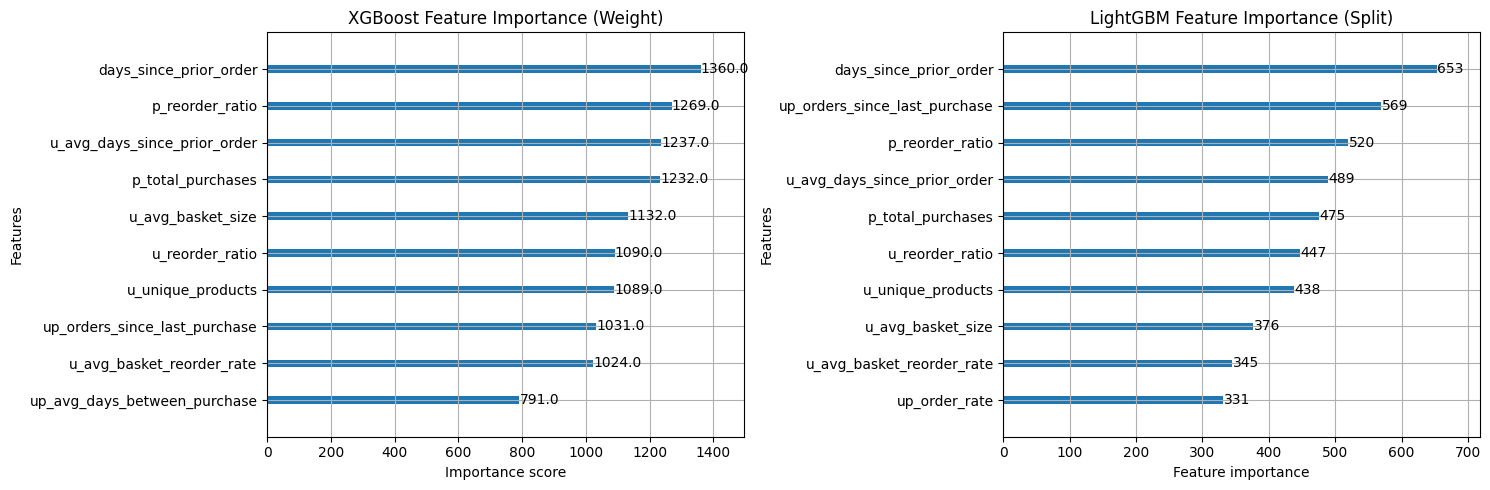

In [60]:
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. XGBoost Feature Importance
# 'weight' = number of times a feature appears in a tree
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, ax=ax1)
ax1.set_title('XGBoost Feature Importance (Weight)')

# 2. LightGBM Feature Importance
# 'split' = number of times the feature is used in a split
lgb.plot_importance(lgbm_model, importance_type='split', max_num_features=10, ax=ax2)
ax2.set_title('LightGBM Feature Importance (Split)')


plt.tight_layout()
plt.show()

The feature importance results from both models reveal that past behavior is the most reliable predictor of future purchases, though they rank specific variables differently based on their mathematical approach. In the XGBoost (Weight) results, the model relies heavily on high-level identifiers like user_id and product_id, suggesting it is highly effective at anchoring predictions to specific "power shoppers" and "staple items" that have a high baseline reorder frequency. It also prioritizes u_avg_days_since_prior_order, which establishes the user's general shopping rhythm. This indicates that XGBoost is performing a broader "profile-based" assessment, identifying which users are habitual and which products (like milk or bananas) are naturally recurring across the entire dataset.

In contrast, the LightGBM (Split) results focus more on fine-grained interaction and temporal triggers. By ranking days_since_prior_order as its top feature, LightGBM is constantly "checking the clock" to see if enough time has passed for a user to run out of a specific item. It also places significant weight on up_orders_since_last_purchase and up_consecutive_streak, which are highly precise indicators of a current habit. While XGBoost looks at who the user is, LightGBM seems more attuned to the urgency and consistency of the specific relationship between a user and a product. Together, these variables show that while the models share a common data foundation, XGBoost excels at identifying static loyalty, while LightGBM excels at capturing dynamic timing.

While we considered creating an Ensemble Model (such as a Weighted Average) to boost our final F1-Score, it was ultimately decided against it due to the high degree of structural similarity between our two top performers.

XGBoost and LightGBM are both members of the Gradient Boosted Decision Tree (GBDT) family. Because they share the same fundamental logic—iteratively correcting errors by building shallow trees—they tend to develop similar "blind spots."

Correlation of Errors: When two models are built on the same feature set using the same mathematical foundations, their predictions become highly correlated. If XGBoost fails to predict a reorder for a "sporadic shopper," LightGBM is likely to fail in the exact same way.

Diminishing Returns: For an ensemble to be truly effective, the models should ideally be uncorrelated. For example, combining a Neural Network (which excels at capturing complex, blurry patterns) with a Random Forest (which excels at tabular, categorical data) would likely yield a higher lift than combining two versions of Gradient Boosting.

Complexity vs. Gain: Given that our individual PR-AUC scores are nearly identical (0.426 vs 0.425), the marginal gain from an ensemble would likely be less than 1%. For a production-level pipeline, the added computational cost and "technical debt" of maintaining two massive tree models often outweigh such a minor statistical improvement.

Final Strategy: The "Single Best" Approach
Rather than splitting our resources across an ensemble of similar trees, we will focus our efforts on Hyperparameter Optimization for a single model. This allows us to maximize the depth and leaf-wise growth of one primary model to capture the nuances of user behavior without the overhead of a redundant ensemble.

In [ ]:
#Things to add, 
# 
# 1. use k-means to determine the type of shoppers
# 2. create a recommendation system


: 